![Logo del Instituto](https://raw.githubusercontent.com/Alelop-Itu/machine12026nocturno/refs/heads/main/img/logoitqv1.jpg)

#  Parcial I

![Logo de Python](https://raw.githubusercontent.com/Alelop-Itu/machine12026nocturno/refs/heads/main/img/python_logo.png)

* Nombre: Alejandra López
* Fecha: **30-09-2026**
* Repositorio: [Link del repositorio de Github](https://github.com/Alelop-Itu/machine12026nocturno2.git)

In [20]:
import os #Kaggle
import numpy as np #matrices
import pandas as pd # Daraframes
import matplotlib.pyplot as plt #gráficos
import seaborn as sns #gráficos
import kagglehub #data

from sklearn.ensemble import IsolationForest #Outliers
from sklearn.model_selection import train_test_split, KFold, cross_validate #Predicción
from sklearn.preprocessing import MinMaxScaler #Normalización
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression #Regresión lineal
from sklearn.pipeline import Pipeline #Encadena pasos de preprocesamiento
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score #métricas

sns.set_theme(style="whitegrid") #gráficos con fondo blanco y cuadrícula
pd.set_option("display.float_format", "{:.3f}".format) Los números muestran 3 valores decimales


## 1. Carga y comprensión de los datos

In [21]:
ruta = kagglehub.dataset_download("mirichoi0218/insurance")
print("Dataset descargado en:", ruta)

df = pd.read_csv(os.path.join(ruta, "insurance.csv"))
df.head()

Dataset descargado en: C:\Users\ALEJANDRA\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [22]:
print("Filas y columnas:", df.shape) #imprime tamaño del dataframe
df.info() #Resumen del dataframe / Detecta valores faltantes y tipos incorrectos

Filas y columnas: (1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [23]:
df.describe(include="all").T #Describe() Calcula las estadísticas descriptivas de cada columna

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.000,NaN,NaN,NaN,39.207,14.050,18.000,27.000,39.000,51.000,64.000
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.000,NaN,NaN,NaN,30.663,6.098,15.960,26.296,30.400,34.694,53.130
children,1338.000,NaN,NaN,NaN,1.095,1.205,0.000,0.000,1.000,2.000,5.000
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.000,NaN,NaN,NaN,13270.422,12110.011,1121.874,4740.287,9382.033,16639.913,63770.428


## 2. EDA y calidad de los datos

In [24]:
print("Valores nulos por columna:")
print(df.isnull().sum()) #Imprime la cantidad de valores faltantes en cada columna
print("\nFilas duplicadas:", df.duplicated().sum())  #Reconoce valores duplicados

Valores nulos por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Filas duplicadas: 1


In [25]:
# Eliminar duplicados
df = df.drop_duplicates().reset_index(drop=True) # Solo se conserva la primera fila y borra el resto repetido
print("Tamaño después de quitar duplicados:", df.shape)

Tamaño después de quitar duplicados: (1337, 7)


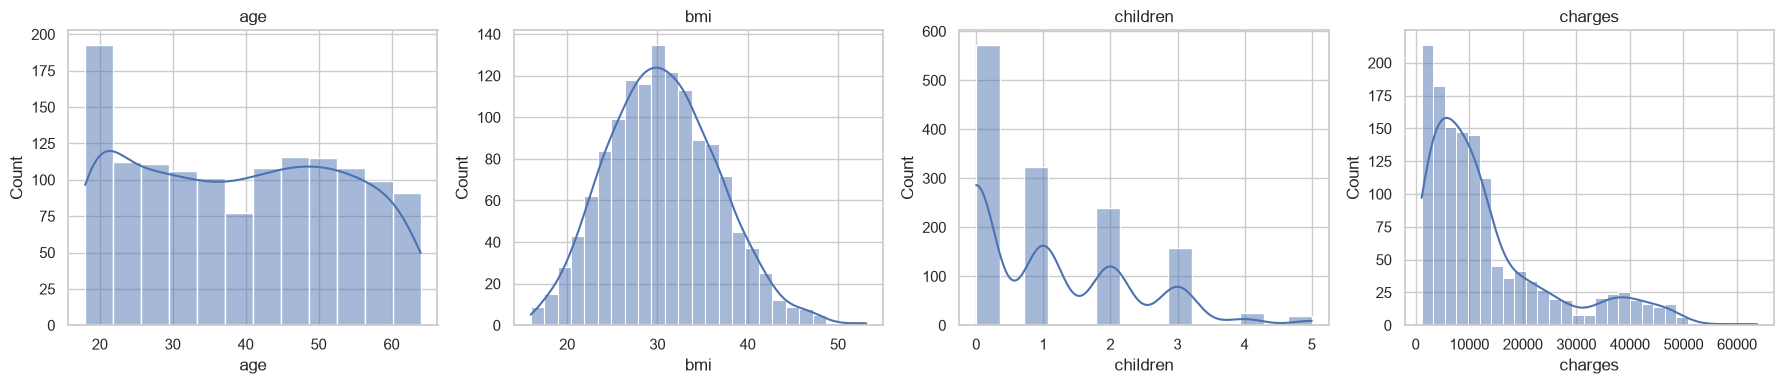

In [26]:
# Distribución de las variables numéricas
num_cols = ["age", "bmi", "children", "charges"] 
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax) #histograma
    ax.set_title(col)
plt.tight_layout()#márgenes
plt.show()

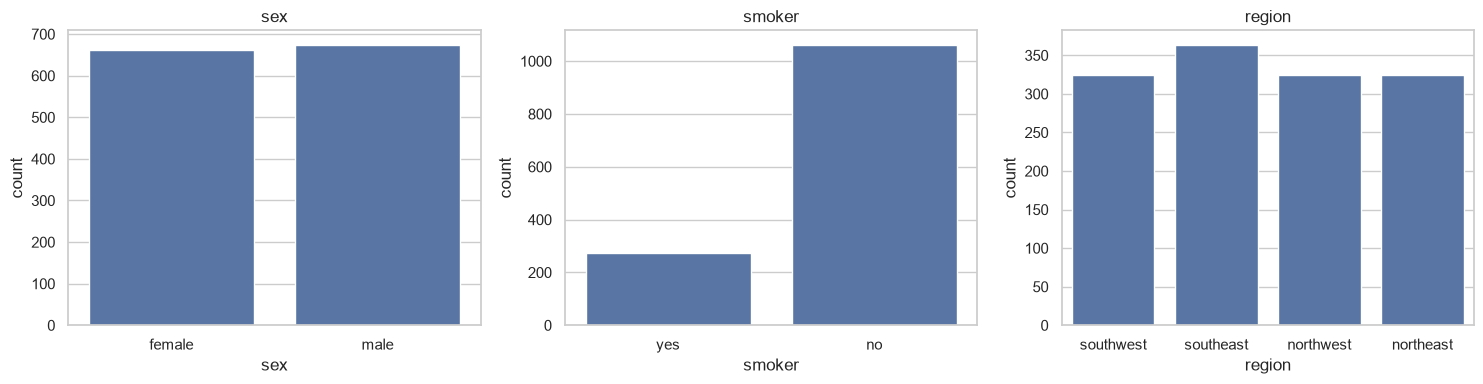

In [27]:
# Distribución de las variables categóricas
cat_cols = ["sex", "smoker", "region"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

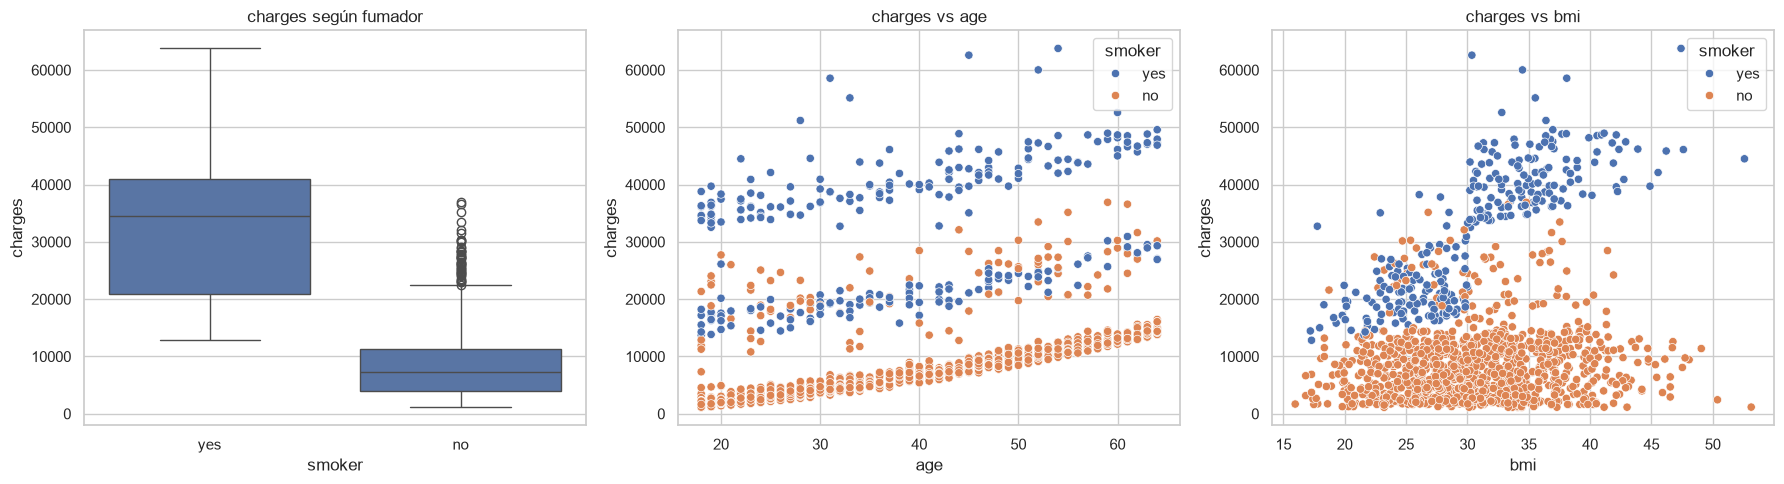

In [28]:
# Relación de las variables con charges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0])
axes[0].set_title("charges según fumador")
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", ax=axes[1])
axes[1].set_title("charges vs age")
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", ax=axes[2])
axes[2].set_title("charges vs bmi")
plt.tight_layout()
plt.show()

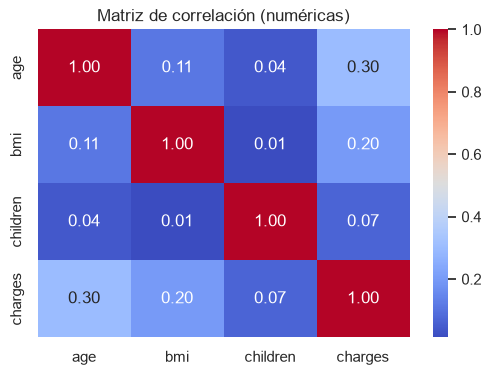

In [29]:
# Correlación entre variables numéricas
plt.figure(figsize=(6, 4)) #Tama{o gráfico
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f") #mapa de calor
plt.title("Matriz de correlación (numéricas)")
plt.show()

## 3. Detección de outliers con Isolation Forest

In [30]:
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42) #Detectar valores anormales
df["outlier"] = iso.fit_predict(df[num_cols]) #entrenemiento del modelo y también se predice

print(df["outlier"].value_counts().rename({1: "normal", -1: "atípico"}))

outlier
normal     1270
atípico      67
Name: count, dtype: int64


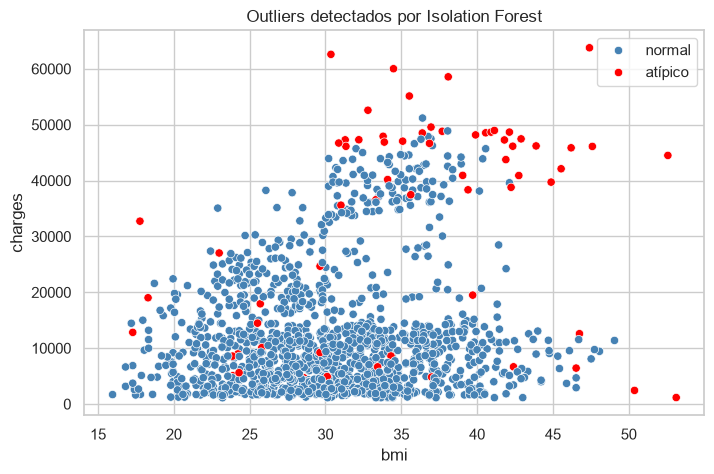

In [31]:
# Visualización de los atípicos detectados
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="bmi", y="charges", hue=df["outlier"].map({1: "normal", -1: "atípico"}), # Gráfico de dispersión
                palette={"normal": "steelblue", "atípico": "red"}) 
plt.title("Outliers detectados por Isolation Forest")
plt.legend(title="")
plt.show()

In [32]:
# Eliminamos los atípicos
df_limpio = df[df["outlier"] == 1].drop(columns="outlier").reset_index(drop=True)
print("Antes:", df.shape[0], "filas  |  Después:", df_limpio.shape[0], "filas")

Antes: 1337 filas  |  Después: 1270 filas


## 4. Preparación de variables

In [33]:
REGIONES = ["northeast", "northwest", "southeast", "southwest"] #Lista fija con las 4 regiones

def preparar_variables(data):
    d = data.copy()
    d["sex"] = d["sex"].map({"female": 0, "male": 1})
    d["smoker"] = d["smoker"].map({"no": 0, "yes": 1})
    d["region"] = pd.Categorical(d["region"], categories=REGIONES)   # categorías fijas
    d = pd.get_dummies(d, columns=["region"], drop_first=True, dtype=int)
    return d

df_prep = preparar_variables(df_limpio)

X = df_prep.drop(columns="charges") #Crea la matriz de variables predictoras X
y = df_prep["charges"]
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,1
1,18,1,33.770,1,0,0,1,0
2,28,1,33.000,3,0,0,1,0
3,33,1,22.705,0,0,1,0,0
4,32,1,28.880,0,0,1,0,0


## 5. Normalización 

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)

scaler = MinMaxScaler()
X_train_norm = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index) #Aparece min y max y convierte a 0 y 1
X_test_norm  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns, index=X_test.index)

X_train_norm.describe().loc[["min", "max"]] #Muestra el mínimo y máximo de cada columna

Entrenamiento: (1016, 8)  Prueba: (254, 8)


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 6. Selección de atributos

In [35]:
selector = SelectKBest(score_func=f_regression, k="all") #Crea um¿n selector que calcula puntaje de cada uno
selector.fit(X_train_norm, y_train) #entrenamiento del modelo

puntajes = pd.DataFrame({
    "variable": X.columns,
    "F_score": selector.scores_,
    "p_valor": selector.pvalues_
}).sort_values("F_score", ascending=False)
puntajes

,variable,F_score,p_valor
4,smoker,1384.585,0.000
0,age,100.777,0.000
2,bmi,12.262,0.000
1,sex,3.238,0.072
3,children,1.829,0.177
7,region_southwest,1.670,0.197
6,region_southeast,0.953,0.329
5,region_northwest,0.533,0.466


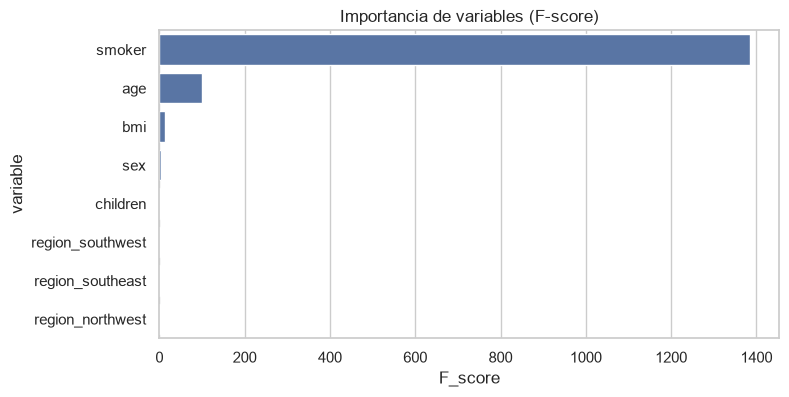

Variables seleccionadas: ['smoker', 'age', 'bmi']


In [36]:
plt.figure(figsize=(8, 4))
sns.barplot(data=puntajes, x="F_score", y="variable") #Gráfico de barras horizontales
plt.title("Importancia de variables (F-score)")
plt.show()

seleccionadas = puntajes.loc[puntajes["p_valor"] < 0.05, "variable"].tolist()
print("Variables seleccionadas:", seleccionadas)

## 7. Validación de datos 

In [37]:
pipeline = Pipeline([
    ("normalizacion", MinMaxScaler()),
    ("regresion", LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42) #entrenamiento y evaluación del pipeline 5 veces
cv = cross_validate(pipeline, X_train[seleccionadas], y_train, cv=kf, 
                    scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"]) $Cálculo de medidas en cada vuelta

print(f"R² promedio:   {cv['test_r2'].mean():.3f} ± {cv['test_r2'].std():.3f}") 
print(f"MAE promedio:  {-cv['test_neg_mean_absolute_error'].mean():,.2f}")
print(f"RMSE promedio: {-cv['test_neg_root_mean_squared_error'].mean():,.2f}")

R² promedio:   0.708 ± 0.049
MAE promedio:  3,883.75
RMSE promedio: 5,737.60


## 8. Entrenamiento mediante Regresión Lineal

In [38]:
modelo = Pipeline([
    ("normalizacion", MinMaxScaler()),
    ("regresion", LinearRegression())
])
modelo.fit(X_train[seleccionadas], y_train)
modelo   # muestra el diagrama del pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('normalizacion', ...), ('regresion', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['smoker','age','bmi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value


In [39]:
reg = modelo.named_steps["regresion"]
print(f"Intercepto (β0): {reg.intercept_:,.2f}")

coeficientes = pd.DataFrame({"variable": seleccionadas, "coeficiente": reg.coef_}) \
                 .sort_values("coeficiente", ascending=False)

Intercepto (β0): -694.96


## 9. Evaluación

In [40]:
y_pred_train = modelo.predict(X_train[seleccionadas])
y_pred = modelo.predict(X_test[seleccionadas])

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² prueba:        {r2:.3f}")
print(f"R² entrenamiento: {r2_score(y_train, y_pred_train):.3f}")

MAE:  3,753.24
MSE:  32,580,107.06
RMSE: 5,707.90
R² prueba:        0.715
R² entrenamiento: 0.717


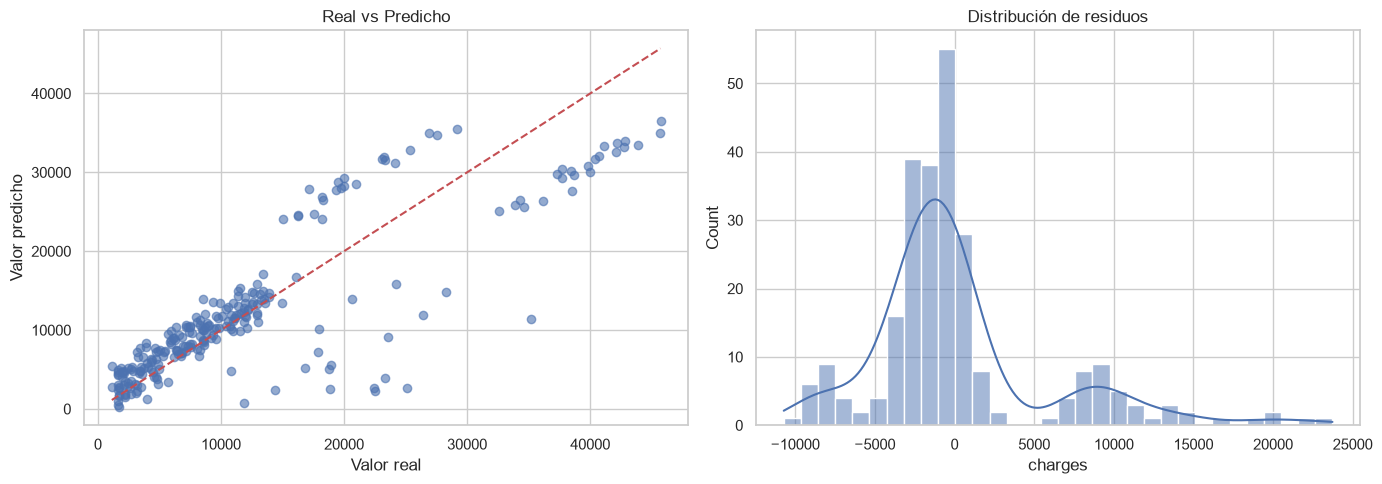

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.6)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Valor real")
axes[0].set_ylabel("Valor predicho")
axes[0].set_title("Real vs Predicho")

residuos = y_test - y_pred
sns.histplot(residuos, kde=True, ax=axes[1])
axes[1].set_title("Distribución de residuos")
plt.tight_layout()
plt.show()

## 10. Predicción con nuevos datos

In [42]:
nuevos = pd.DataFrame({
    "age":      [25, 45, 60],
    "sex":      ["female", "male", "male"],
    "bmi":      [22.5, 31.0, 28.3],
    "children": [0, 2, 1],
    "smoker":   ["no", "yes", "no"],
    "region":   ["northwest", "southeast", "southwest"]
})

X_nuevo = preparar_variables(nuevos).reindex(columns=X.columns, fill_value=0)[seleccionadas]
nuevos["charges_estimado"] = modelo.predict(X_nuevo).round(2)
nuevos

,age,sex,bmi,children,smoker,region,charges_estimado
0,25,female,22.500,0,no,northwest,2690.310
1,45,male,31.000,2,yes,southeast,31911.710
2,60,male,28.300,1,no,southwest,13078.390
